In [1]:
# Validation notebook: single best model. K from mean_NORM_con_22.csv, t_step=0.01, t_max=40.
# Transform held-out validation data and plot beta + spaghetti (no candidate comparison).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from EMDPM.utils import solve_system
from EMDPM.em_transformer_rework import EM
from sklearn.model_selection import train_test_split

# Paths and settings
K_PATH = "/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv"
PPMI_CSV = "/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv"
NPZ_PATH = "/home/dsemchin/Progression_models_simulations/EMDPM/experiments/qsub_jobs/presubtyping_results/f_init_candidate_3_scld.npz"

t_max = 40
t_step = 0.01
n_biomarkers = 68

biomarker_names = ['L_bankssts_thickavg', 'L_caudalanteriorcingulate_thickavg', 'L_caudalmiddlefrontal_thickavg', 'L_cuneus_thickavg',
                   'L_entorhinal_thickavg', 'L_fusiform_thickavg', 'L_inferiorparietal_thickavg', 'L_inferiortemporal_thickavg',
                   'L_isthmuscingulate_thickavg', 'L_lateraloccipital_thickavg', 'L_lateralorbitofrontal_thickavg',
                   'L_lingual_thickavg', 'L_medialorbitofrontal_thickavg', 'L_middletemporal_thickavg', 'L_parahippocampal_thickavg',
                   'L_paracentral_thickavg', 'L_parsopercularis_thickavg', 'L_parsorbitalis_thickavg', 'L_parstriangularis_thickavg',
                   'L_pericalcarine_thickavg', 'L_postcentral_thickavg', 'L_posteriorcingulate_thickavg', 'L_precentral_thickavg',
                   'L_precuneus_thickavg', 'L_rostralanteriorcingulate_thickavg', 'L_rostralmiddlefrontal_thickavg', 'L_superiorfrontal_thickavg',
                   'L_superiorparietal_thickavg', 'L_superiortemporal_thickavg', 'L_supramarginal_thickavg', 'L_frontalpole_thickavg',
                   'L_temporalpole_thickavg', 'L_transversetemporal_thickavg', 'L_insula_thickavg', 'R_bankssts_thickavg', 'R_caudalanteriorcingulate_thickavg',
                   'R_caudalmiddlefrontal_thickavg', 'R_cuneus_thickavg', 'R_entorhinal_thickavg', 'R_fusiform_thickavg', 'R_inferiorparietal_thickavg',
                   'R_inferiortemporal_thickavg', 'R_isthmuscingulate_thickavg', 'R_lateraloccipital_thickavg', 'R_lateralorbitofrontal_thickavg',
                   'R_lingual_thickavg', 'R_medialorbitofrontal_thickavg', 'R_middletemporal_thickavg', 'R_parahippocampal_thickavg', 'R_paracentral_thickavg',
                   'R_parsopercularis_thickavg', 'R_parsorbitalis_thickavg', 'R_parstriangularis_thickavg', 'R_pericalcarine_thickavg', 'R_postcentral_thickavg',
                   'R_posteriorcingulate_thickavg', 'R_precentral_thickavg', 'R_precuneus_thickavg', 'R_rostralanteriorcingulate_thickavg',
                   'R_rostralmiddlefrontal_thickavg', 'R_superiorfrontal_thickavg', 'R_superiorparietal_thickavg', 'R_superiortemporal_thickavg',
                   'R_supramarginal_thickavg', 'R_frontalpole_thickavg', 'R_temporalpole_thickavg', 'R_transversetemporal_thickavg', 'R_insula_thickavg']

ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]
ROI_names = [biomarker_names[i] for i in ROI]

In [2]:
# Load connectivity matrix K
df_K = pd.read_csv(K_PATH)
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum
print("K shape:", K.shape)

K shape: (68, 68)


Loaded npz keys: ['theta_history', 'cog_history', 'beta_history', 'lse_history', 'beta_val', 'candidate', 'f_init']
Final train LSE (from npz): 530.6888031047707


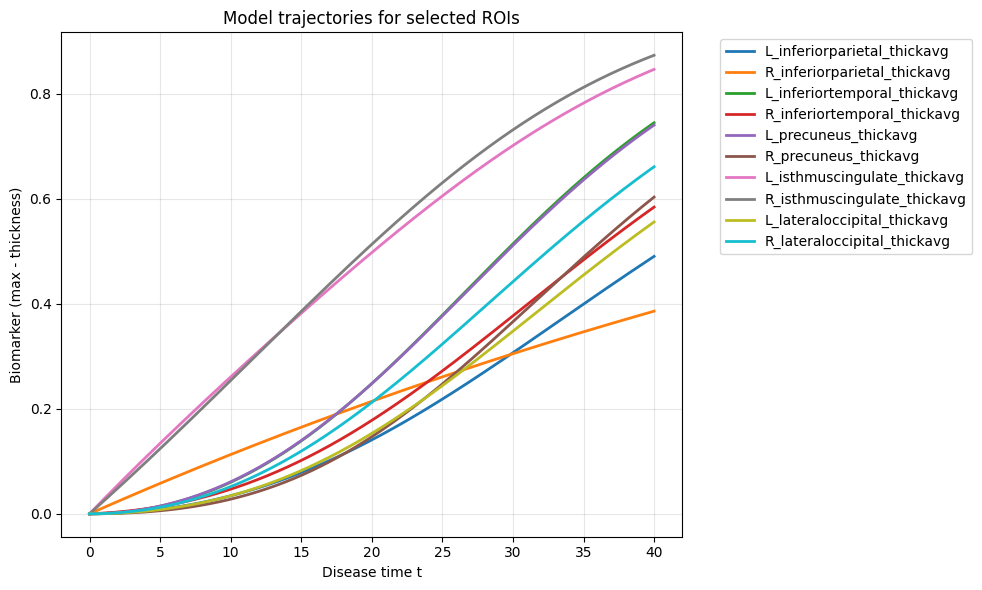

In [3]:
# Load best model from npz and build EM for transform (no fit)
data = np.load(NPZ_PATH, allow_pickle=True)
print("Loaded npz keys:", list(data.files))

theta = data["theta_history"][:, -1]
cog_history = data["cog_history"]
cog_a = cog_history[:-1, -1]
cog_b = cog_history[-1, -1]

em = EM(K=K, t_max=t_max, step=t_step, lambda_f=0.01, lambda_cog=0.0, lambda_scalar=0.0, jac_toggle=True, verbose=0)
em.theta = theta
em.cog_a = cog_a
em.cog_b = cog_b
em.t_span = np.linspace(0, em.t_max, int(em.t_max / em.step))
em.X_pred = solve_system(np.zeros(n_biomarkers), theta[:n_biomarkers], K, em.t_span, theta[-1])

print("Final train LSE (from npz):", data["lse_history"][-1])

s = em.theta[n_biomarkers : 2 * n_biomarkers]

plt.figure(figsize=(10, 6))

for i, roi in enumerate(ROI):
    color = plt.cm.tab10(i % 10)  # tab10 has 10 distinct colors
    traj = em.X_pred[roi] #* s[roi]  # model trajectory for this biomarker
    plt.plot(em.t_span, traj, color=color, lw=2, label=ROI_names[i])

plt.xlabel("Disease time t")
plt.ylabel("Biomarker (max - thickness)")
plt.title("Model trajectories for selected ROIs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Load PPMI data, build patient list.
# For another PD dataset: same preprocessing, then set USE_TRAIN_VAL_SPLIT = False
# so that X_val = X_all (no split) and transform/plots use all subjects.
USE_TRAIN_VAL_SPLIT = True  # False = use all data as "validation" (no held-out split)

df = pd.read_csv(PPMI_CSV)
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]

print(df.shape)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)
print(df.shape)

print(df[["subj_id", "time", "NHY"]].head(4))

subj_counts = df['subj_id'].value_counts()

print(f'total subjects: {len(subj_counts)}')

longitudinal_ids = subj_counts[subj_counts > 1].index

print(f'longitudinal subjects: {len(longitudinal_ids)}')

df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.drop_duplicates(subset=["subj_id", "time"])

X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs

dt_all = (df["time"].to_numpy() / 12.0)
ids_all = df["subj_id"].to_numpy()
nhy_all = df["NHY"].to_numpy()
cog_all = df[["MCATOT", "TD_score", "PIGD_score"]].to_numpy()

def create_patient_list(X_obs, ids, dt, cog, nhy):
    unique_ids = np.unique(ids)
    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_list.append({
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask],
            "nhy": nhy[mask],
        })
    return patient_list

X_all = create_patient_list(X_obs, ids_all, dt_all, cog_all, nhy_all)
if USE_TRAIN_VAL_SPLIT:
    X_train, X_val = train_test_split(X_all, test_size=0.2, random_state=75)
    print("n_train:", len(X_train), "n_val:", len(X_val))
else:
    X_train, X_val = [], X_all
    print("No split: using all", len(X_val), "subjects as validation set.")

(880, 250)
(868, 250)
   subj_id  time  NHY
0     4107     0  2.0
2     3275     0  2.0
3     3279     0  2.0
4     3076     0  2.0
total subjects: 373
longitudinal subjects: 146
n_train: 116 n_val: 30


In [5]:
# Transform validation set: estimate betas and compute validation LSE
beta_val = em.transform(X_val)
val_lse = em._compute_val_score(X_val, beta_val)
print("Validation LSE:", val_lse)
print("Validation betas: min=%.4f, max=%.4f, mean=%.4f" % (beta_val.min(), beta_val.max(), beta_val.mean()))

Estimating beta values:   0%|          | 0/30 [00:00<?, ?it/s]

Estimating beta values: 100%|██████████| 30/30 [00:00<00:00, 61.97it/s]

Validation LSE: 133.47947951101165
Validation betas: min=19.1826, max=34.3636, mean=26.8887


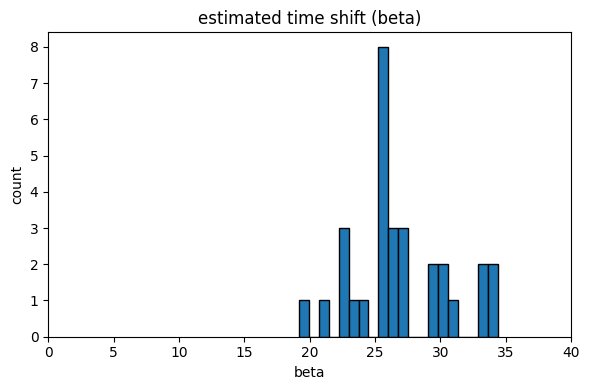

In [6]:
# Beta distribution (validation set)
plt.figure(figsize=(6, 4))
plt.hist(beta_val, bins=20, edgecolor="k")
plt.xlabel("beta")
plt.ylabel("count")
plt.title("estimated time shift (beta)")
plt.xlim(0,40)
plt.tight_layout()
plt.show()


/tmp/ipykernel_9824/1571936370.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_val, x="NHY", y="t_ij", palette="plasma", inner="box")


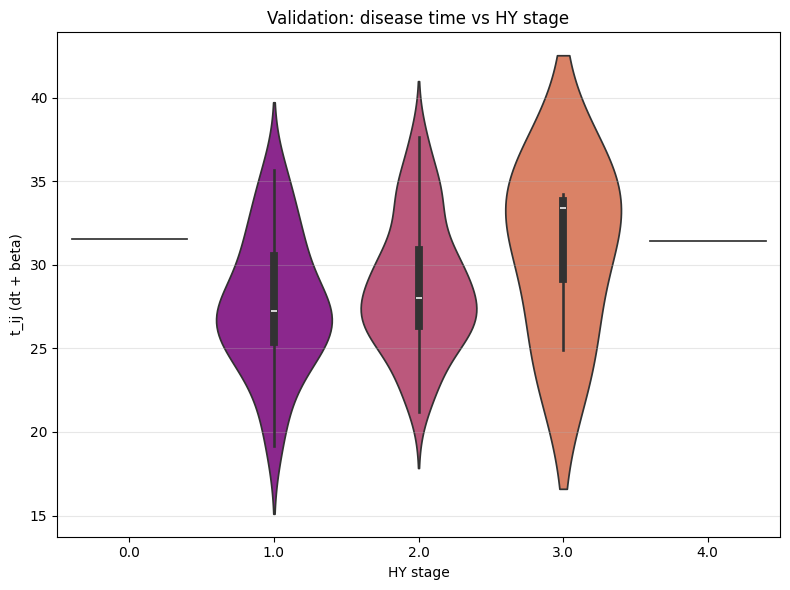

/tmp/ipykernel_9824/1571936370.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_beta, x="NHY", y="beta", palette="plasma", inner="box")


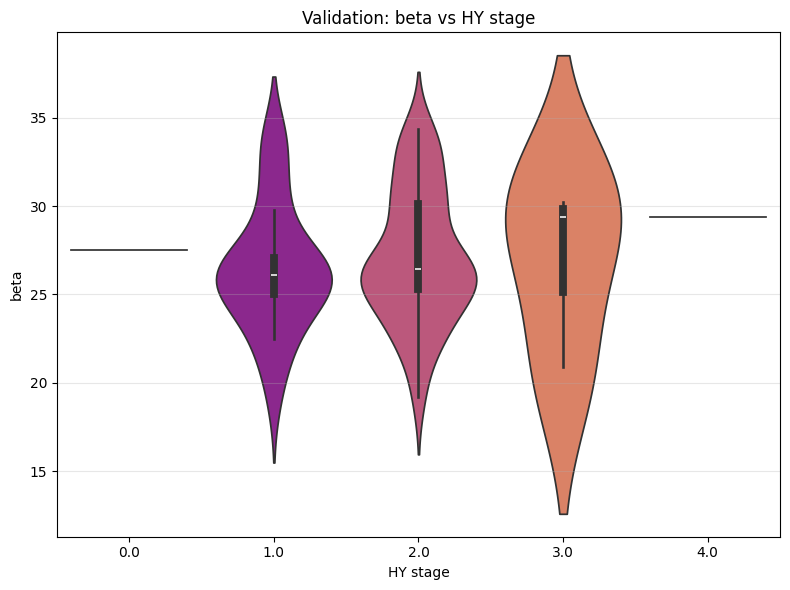

In [7]:
# t_ij = dt + beta per visit for validation; violin NHY vs t_ij
t_ij_val = np.concatenate([p["dt"] + beta_val[i] for i, p in enumerate(X_val)])
nhy_val = np.concatenate([p["nhy"] for p in X_val])
df_val = pd.DataFrame({"t_ij": t_ij_val, "NHY": nhy_val}).dropna()
plt.figure(figsize=(8, 6))
sns.violinplot(data=df_val, x="NHY", y="t_ij", palette="plasma", inner="box")
plt.xlabel("HY stage")
plt.ylabel("t_ij (dt + beta)")
plt.title("Validation: disease time vs HY stage")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# beta per visit for validation; violin NHY vs beta
# beta_val = np.concatenate([beta_val[i] for i, p in enumerate(X_val)])
beta_per_visit = np.concatenate([
    np.full_like(p["dt"], beta_val[i], dtype=float)
    for i, p in enumerate(X_val)
])
nhy_val = np.concatenate([p["nhy"] for p in X_val])

df_beta = pd.DataFrame({"beta": beta_per_visit, "NHY": nhy_val}).dropna()

plt.figure(figsize=(8, 6))
sns.violinplot(data=df_beta, x="NHY", y="beta", palette="plasma", inner="box")
plt.xlabel("HY stage")
plt.ylabel("beta")
plt.title("Validation: beta vs HY stage")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9824/2589365461.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


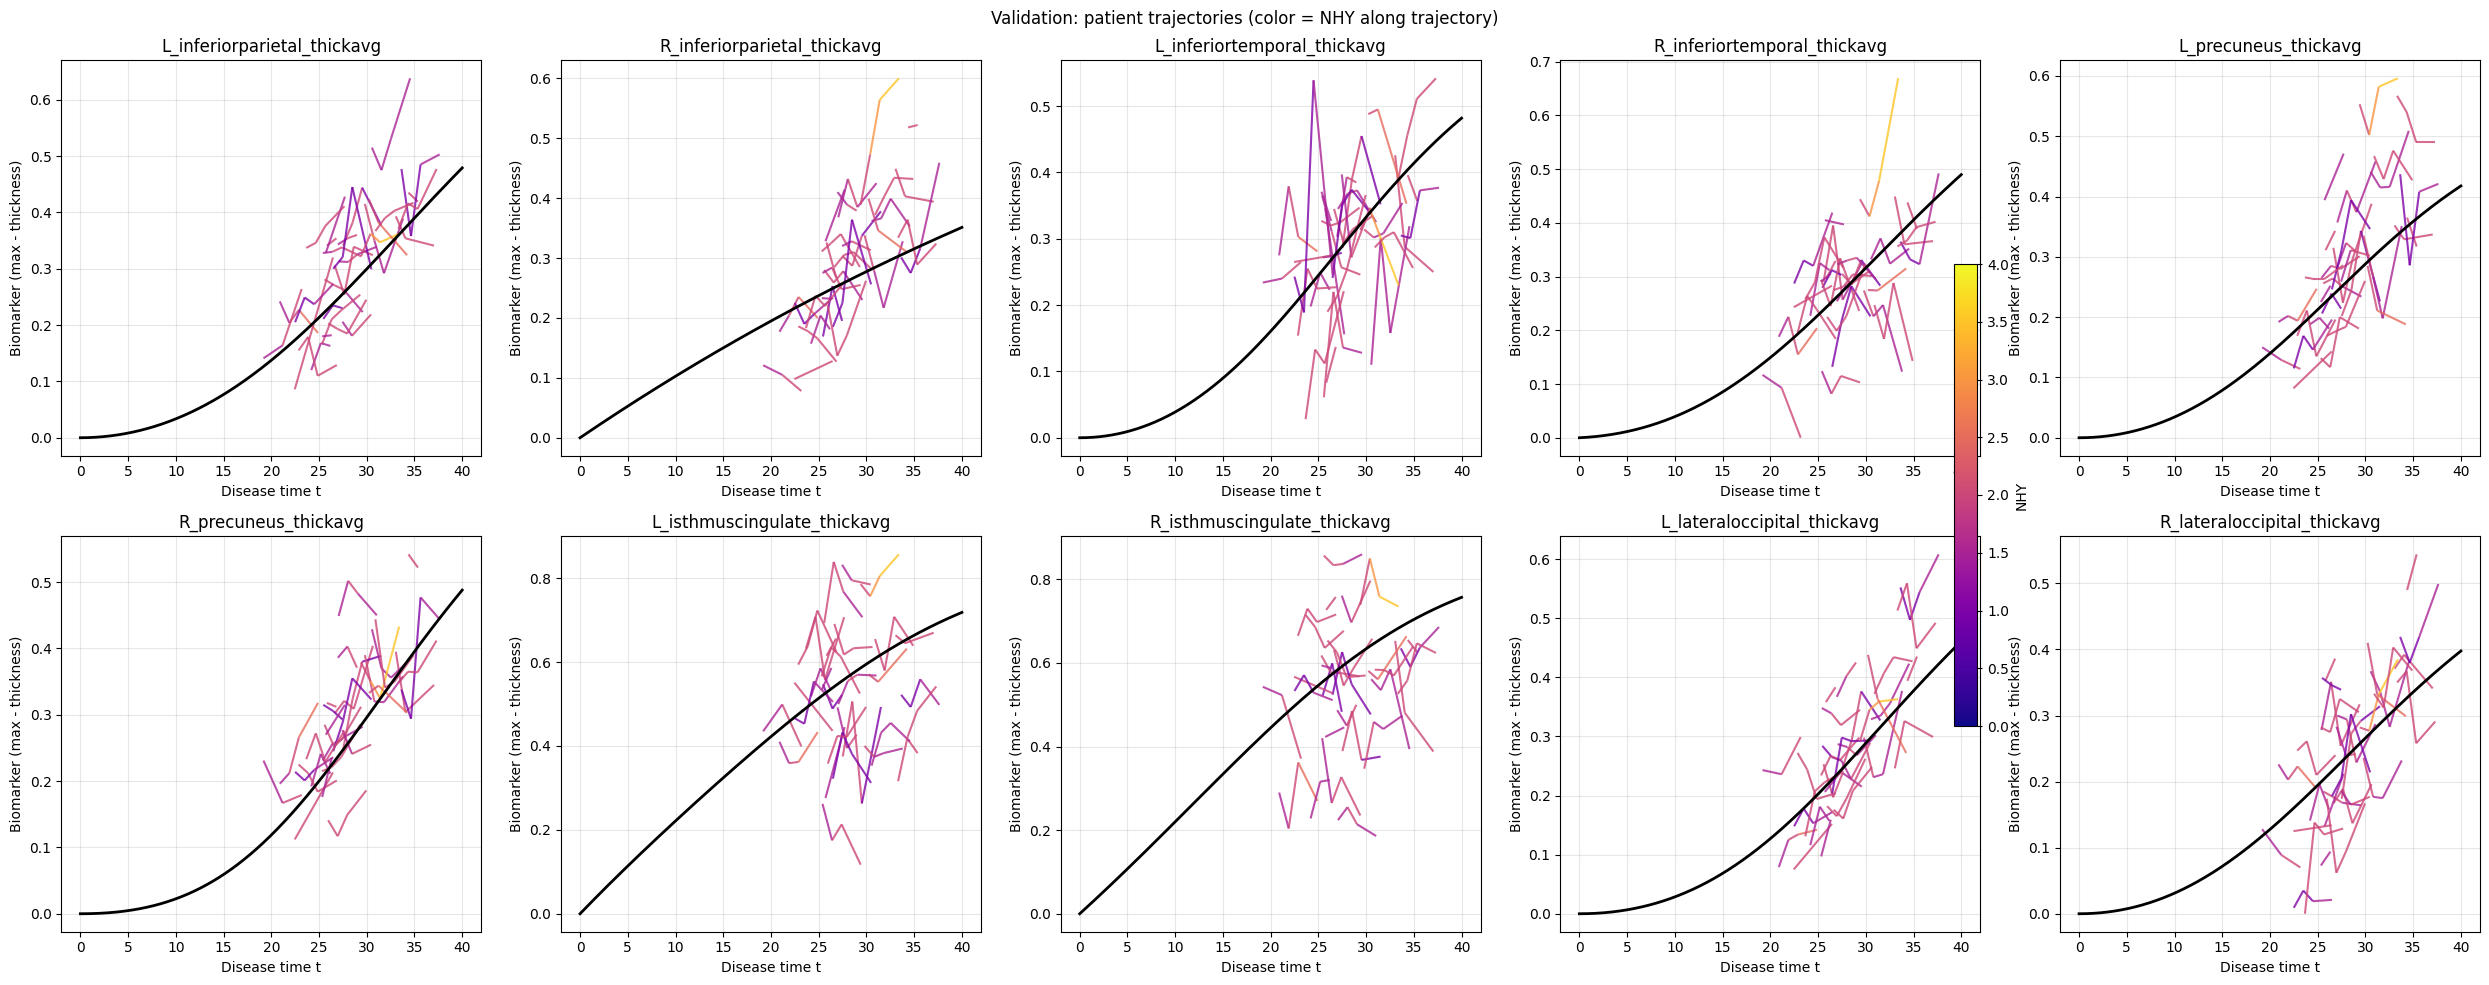

In [8]:
# Spaghetti plot: ROIs, validation patients — lines colored by NHY gradient along trajectory
from matplotlib.collections import LineCollection

s = em.theta[n_biomarkers : 2 * n_biomarkers]
n_patients_show = len(X_val)
rng = np.random.default_rng(42)
idx_show = rng.choice(len(X_val), size=n_patients_show, replace=False)

# Collect all NHY values on the plot for a consistent color scale
all_nhy = np.concatenate([X_val[i]["nhy"] for i in idx_show])
norm_nhy = plt.Normalize(vmin=all_nhy.min(), vmax=all_nhy.max())
cmap = plt.cm.plasma

n_rois = len(ROI)
fig, axes = plt.subplots(2, 5, figsize=(5 * 5, 5 * 2))
axes = axes.flatten()

for j, (ax, roi) in enumerate(zip(axes, ROI)):
    for i in idx_show:
        p = X_val[i]
        t_ij = p["dt"] + beta_val[i]
        y = p["X_obs"][:, roi]
        nhy = p["nhy"]

        order = np.argsort(t_ij)
        t_sorted = t_ij[order]
        y_sorted = y[order]
        nhy_sorted = nhy[order]

        # Segments: from (t[k], y[k]) to (t[k+1], y[k+1])
        pts = np.column_stack([t_sorted, y_sorted])
        segments = np.stack([pts[:-1], pts[1:]], axis=1)
        # Color each segment by average NHY at its two endpoints (gradient between visits)
        nhy_mid = 0.5 * (nhy_sorted[:-1] + nhy_sorted[1:])
        colors = cmap(norm_nhy(nhy_mid))

        lc = LineCollection(segments, colors=colors, alpha=0.8, lw=1.5)
        ax.add_collection(lc)

    ax.plot(em.t_span, s[roi] * em.X_pred[roi], "k-", lw=2, label="Model")
    ax.set_xlabel("Disease time t")
    ax.set_ylabel("Biomarker (max - thickness)")
    ax.set_title(ROI_names[j])
    ax.grid(True, alpha=0.3)
    ax.autoscale()  # needed after LineCollection

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_nhy)
sm.set_array([])
fig.colorbar(sm, ax=axes, shrink=0.6, label="NHY")
plt.suptitle("Validation: patient trajectories (color = NHY along trajectory)")
plt.tight_layout()
plt.show()